# 05 — Hypothesis tests, tables and figures

Turns the canonical `results/runs.csv` (480 runs) into the paper's numbers.
Every value in the manuscript comes from a CSV this notebook writes; nothing is
typed by hand.

Scope rules, fixed before reading any result:

- **Valid:** multiclass `random_70_30`; binary `random_70_30`; binary `day_ordered`.
- **Excluded as degenerate:** multiclass `day_ordered` — attack families are
  day-segregated in CICIDS2017, so the masked test collapses toward one class.
  Reported in the appendix table with that rationale, because a pre-registered
  design catching its own flaw is a result, not an embarrassment.
- Day-ordered splits are deterministic, so seed variation comes from model
  randomness only; logistic regression is deterministic there (SD 0). Where a
  configuration has zero variance across seeds, the Wilcoxon test is undefined —
  the mean difference is reported and the test skipped, marked `var0`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
DRIVE_ROOT = '/content/drive/MyDrive/research/ids-label-correction'
sys.path.insert(0, os.path.join(DRIVE_ROOT, 'src'))

import importlib, config as C, helpers as H
importlib.reload(C); importlib.reload(H)

import pandas as pd, numpy as np, json
from scipy import stats
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

runs = pd.read_csv(os.path.join(C.RESULTS, 'runs.csv'))
runs = runs.drop_duplicates(subset='run_id', keep='last')
runs['task'] = runs.get('task', 'multiclass')
runs['task'] = runs['task'].fillna('multiclass')

METRICS = ['macro_f1', 'weighted_f1', 'balanced_acc', 'mcc', 'accuracy',
           'attack_recall', 'attack_precision', 'benign_fpr']
for m in METRICS:
    if m in runs.columns:
        runs[m] = pd.to_numeric(runs[m], errors='coerce')

print(len(runs), 'unique runs')
print(runs.groupby(['task', 'arm', 'split']).size().to_string())

VALID = runs[(runs['task'] == 'binary') |
             ((runs['task'] == 'multiclass') & (runs['split'] == 'random_70_30'))].copy()
DEGEN = runs[(runs['task'] == 'multiclass') & (runs['split'] == 'day_ordered')].copy()
print(f'\nvalid: {len(VALID)}   excluded degenerate: {len(DEGEN)}')

Mounted at /content/drive
360 unique runs
task        arm  split       
binary      A    day_ordered     60
                 random_70_30    60
            B    day_ordered     30
                 random_70_30    30
multiclass  A    day_ordered     60
                 random_70_30    60
            B    day_ordered     30
                 random_70_30    30

valid: 270   excluded degenerate: 90


In [2]:
# --- shared machinery --------------------------------------------------------
def paired(g, col_version, a_name, b_name, metric):
    a = g[g[col_version] == a_name].sort_values('seed')[metric].values
    b = g[g[col_version] == b_name].sort_values('seed')[metric].values
    if len(a) != len(b) or len(a) < 3 or np.isnan(a).any() or np.isnan(b).any():
        return None
    d = a - b
    if np.allclose(d.std(ddof=0), 0):
        p, note = np.nan, 'var0'
    else:
        try:
            _, p = stats.wilcoxon(a, b)
            note = ''
        except ValueError:
            p, note = np.nan, 'var0'
    return {'a_mean': a.mean(), 'a_sd': a.std(ddof=1),
            'b_mean': b.mean(), 'b_sd': b.std(ddof=1),
            'delta': a.mean() - b.mean(), 'wilcoxon_p': p,
            'cliffs_delta': H.cliffs_delta(a, b), 'n_seeds': len(a), 'note': note}


def holm(df, pcol='wilcoxon_p'):
    p = df[pcol].values.astype(float)
    ok = ~np.isnan(p)
    m = ok.sum()
    adj = np.full(len(p), np.nan)
    order = np.argsort(p[ok])
    idx_ok = np.where(ok)[0][order]
    prev = 0.0
    for rank, i in enumerate(idx_ok):
        val = (m - rank) * p[i]
        prev = max(prev, min(val, 1.0))
        adj[i] = prev
    df = df.copy()
    df['p_holm'] = adj
    return df

In [3]:
# --- H1: does the original score differently from the improved? --------------
# Sign convention: delta = original - improved. Pre-registered H1 predicted
# delta > 0 (original inflated). delta < 0 falsifies H1.
rows = []
A = VALID[(VALID['arm'] == 'A') &
          (VALID['attempted'].isin(['as_attack']))]
for (task, split, model), g in A.groupby(['task', 'split', 'model']):
    r = paired(g, 'version', 'original', 'improved', 'macro_f1')
    if r:
        rows.append({'task': task, 'split': split, 'model': model, **r})

h1 = holm(pd.DataFrame(rows))
h1 = h1.rename(columns={'a_mean': 'original_mean', 'a_sd': 'original_sd',
                        'b_mean': 'improved_mean', 'b_sd': 'improved_sd'})
H.save_table(h1.round(4), 'h1_dataset_level.csv')

# Computed verdict — never a hardcoded conclusion.
neg = (h1['delta'] < 0)
if neg.all():
    print('H1 verdict: FALSIFIED in every configuration (improved scores higher).')
elif not neg.any():
    print('H1 verdict: CONFIRMED in every configuration (original scores higher).')
else:
    print('H1 verdict: SPLIT-DEPENDENT —')
    for _, r in h1.iterrows():
        d = 'improved higher (falsifies H1)' if r['delta'] < 0 else 'original higher'
        print(f"  {r['task']:10s} {r['split']:13s} {r['model']:14s} delta={r['delta']:+.4f}  {d}")
    print('Interpretation note: Arm A day-ordered compares DIFFERENT test sets')
    print('(the improved Thu-Fri test contains ~71k relabelled Infiltration flows');
    print('unlearnable from Mon-Wed training) — the clean per-flow comparison is Arm B.')
h1.round(4)

saved /content/drive/MyDrive/research/ids-label-correction/results/h1_dataset_level.csv (9, 13)
H1 verdict: SPLIT-DEPENDENT —
  binary     day_ordered   logreg         delta=+0.0953  original higher
  binary     day_ordered   random_forest  delta=+0.0263  original higher
  binary     day_ordered   xgboost        delta=-0.1933  improved higher (falsifies H1)
  binary     random_70_30  logreg         delta=-0.0879  improved higher (falsifies H1)
  binary     random_70_30  random_forest  delta=-0.0005  improved higher (falsifies H1)
  binary     random_70_30  xgboost        delta=-0.0003  improved higher (falsifies H1)
  multiclass random_70_30  logreg         delta=-0.1248  improved higher (falsifies H1)
  multiclass random_70_30  random_forest  delta=-0.0312  improved higher (falsifies H1)
  multiclass random_70_30  xgboost        delta=-0.1278  improved higher (falsifies H1)
Interpretation note: Arm A day-ordered compares DIFFERENT test sets
(the improved Thu-Fri test contains ~71k rel

,task,split,model,original_mean,original_sd,improved_mean,improved_sd,delta,wilcoxon_p,cliffs_delta,n_seeds,note,p_holm
0,binary,day_ordered,logreg,0.7401,0.0000,0.6448,0.0000,0.0953,NaN,1.0,5,var0,NaN
1,binary,day_ordered,random_forest,0.6617,0.0068,0.6355,0.0010,0.0263,0.0625,1.0,5,,0.4375
2,binary,day_ordered,xgboost,0.4393,0.0000,0.6326,0.0000,-0.1933,NaN,-1.0,5,var0,NaN
3,binary,random_70_30,logreg,0.8993,0.0009,0.9871,0.0003,-0.0879,0.0625,-1.0,5,,0.4375
4,binary,random_70_30,random_forest,0.9994,0.0000,0.9999,0.0000,-0.0005,0.0625,-1.0,5,,0.4375
5,binary,random_70_30,xgboost,0.9997,0.0000,1.0000,0.0000,-0.0003,0.0625,-1.0,5,,0.4375
6,multiclass,random_70_30,logreg,0.6671,0.0207,0.7919,0.0141,-0.1248,0.0625,-1.0,5,,0.4375
7,multiclass,random_70_30,random_forest,0.9641,0.0253,0.9953,0.0002,-0.0312,0.0625,-1.0,5,,0.4375
8,multiclass,random_70_30,xgboost,0.8524,0.0926,0.9801,0.0170,-0.1278,0.0625,-1.0,5,,0.4375


In [4]:
# --- H2: how much is labels alone? (Arm B) -----------------------------------
rows = []
B = VALID[VALID['arm'] == 'B']
for (task, split, model), g in B.groupby(['task', 'split', 'model']):
    r = paired(g, 'version', 'label_original', 'label_improved', 'macro_f1')
    if r:
        rows.append({'task': task, 'split': split, 'model': model, **r})

h2 = holm(pd.DataFrame(rows))
h2 = h2.rename(columns={'a_mean': 'labels_original_mean', 'a_sd': 'labels_original_sd',
                        'b_mean': 'labels_improved_mean', 'b_sd': 'labels_improved_sd',
                        'delta': 'armB_delta'})
if len(h2) and len(h1):
    h2 = h2.merge(h1[['task', 'split', 'model', 'delta']]
                    .rename(columns={'delta': 'armA_delta'}),
                  on=['task', 'split', 'model'], how='left')
    with np.errstate(divide='ignore', invalid='ignore'):
        h2['share_of_armA_gap'] = (h2['armB_delta'] / h2['armA_delta']).round(3)

H.save_table(h2.round(4), 'h2_label_isolation.csv')
h2.round(4)

saved /content/drive/MyDrive/research/ids-label-correction/results/h2_label_isolation.csv (9, 15)


,task,split,model,labels_original_mean,labels_original_sd,labels_improved_mean,labels_improved_sd,armB_delta,wilcoxon_p,cliffs_delta,n_seeds,note,p_holm,armA_delta,share_of_armA_gap
0,binary,day_ordered,logreg,0.5610,0.0000,0.6223,0.0000,-0.0613,NaN,-1.00,5,var0,NaN,0.0953,-0.643
1,binary,day_ordered,random_forest,0.4340,0.0000,0.4053,0.0029,0.0287,0.0625,1.00,5,,0.4375,0.0263,1.095
2,binary,day_ordered,xgboost,0.4572,0.0000,0.4529,0.0000,0.0043,NaN,1.00,5,var0,NaN,-0.1933,-0.022
3,binary,random_70_30,logreg,0.9649,0.0005,0.9910,0.0003,-0.0261,0.0625,-1.00,5,,0.4375,-0.0879,0.297
4,binary,random_70_30,random_forest,0.9999,0.0000,0.9999,0.0000,-0.0000,0.6250,-0.20,5,,0.9375,-0.0005,0.012
5,binary,random_70_30,xgboost,0.9999,0.0000,0.9999,0.0000,-0.0000,0.3125,-0.28,5,,0.9375,-0.0003,0.024
6,multiclass,random_70_30,logreg,0.6906,0.0239,0.7420,0.0395,-0.0514,0.1250,-0.68,5,,0.5000,-0.1248,0.412
7,multiclass,random_70_30,random_forest,0.8679,0.0094,0.9958,0.0019,-0.1279,0.0625,-1.00,5,,0.4375,-0.0312,4.099
8,multiclass,random_70_30,xgboost,0.7580,0.0962,0.8745,0.1853,-0.1165,0.3125,-0.60,5,,0.9375,-0.1278,0.912


In [5]:
# --- H3: attempted-policy sensitivity (improved only) ------------------------
rows = []
imp = VALID[(VALID['arm'] == 'A') & (VALID['version'] == 'improved')]
for (task, split, model), g in imp.groupby(['task', 'split', 'model']):
    means = g.groupby('attempted')['macro_f1'].mean()
    if len(means) < 2:
        continue
    rows.append({'task': task, 'split': split, 'model': model,
                 **{k: round(v, 4) for k, v in means.items()},
                 'spread': round(float(means.max() - means.min()), 4),
                 'exceeds_0.01': bool((means.max() - means.min()) > 0.01)})

h3 = pd.DataFrame(rows)
H.save_table(h3, 'h3_attempted_sensitivity.csv')
h3

saved /content/drive/MyDrive/research/ids-label-correction/results/h3_attempted_sensitivity.csv (9, 8)


,task,split,model,as_attack,as_benign,dropped,spread,exceeds_0.01
0,binary,day_ordered,logreg,0.6448,0.6479,0.6472,0.0031,False
1,binary,day_ordered,random_forest,0.6355,0.6378,0.6397,0.0042,False
2,binary,day_ordered,xgboost,0.6326,0.5114,0.5976,0.1212,True
3,binary,random_70_30,logreg,0.9871,0.9895,0.9921,0.0050,False
4,binary,random_70_30,random_forest,0.9999,0.9999,0.9999,0.0000,False
5,binary,random_70_30,xgboost,1.0000,1.0000,1.0000,0.0000,False
6,multiclass,random_70_30,logreg,0.7919,0.9240,0.9133,0.1321,True
7,multiclass,random_70_30,random_forest,0.9953,0.9849,0.9880,0.0104,True
8,multiclass,random_70_30,xgboost,0.9801,0.9786,0.9484,0.0318,True


In [6]:
# --- H4: TOST equivalence on Arm B (positive control, macro-F1 proxy) --------
# Note: the pre-registered per-class control (PortScan/DDoS recall) needs stored
# predictions; this proxy tests overall equivalence and carries that caveat.
def tost(a, b, margin):
    d = np.asarray(a) - np.asarray(b)
    n = len(d)
    if n < 2 or d.std(ddof=1) == 0:
        return {'mean_diff': float(d.mean()),
                'p_tost': 0.0 if abs(d.mean()) < margin else 1.0, 'note': 'var0'}
    se = d.std(ddof=1) / np.sqrt(n)
    t_low = (d.mean() + margin) / se
    t_up = (d.mean() - margin) / se
    p = max(1 - stats.t.cdf(t_low, n - 1), stats.t.cdf(t_up, n - 1))
    return {'mean_diff': float(d.mean()), 'p_tost': float(p), 'note': ''}

rows = []
for (task, split, model), g in B.groupby(['task', 'split', 'model']):
    a = g[g['version'] == 'label_original'].sort_values('seed')['macro_f1'].values
    b = g[g['version'] == 'label_improved'].sort_values('seed')['macro_f1'].values
    if len(a) != len(b) or len(a) < 3:
        continue
    r = tost(a, b, C.EQUIV_MARGIN)
    rows.append({'task': task, 'split': split, 'model': model, **r,
                 'equivalent_at_0.02': r['p_tost'] < 0.05})

h4 = pd.DataFrame(rows)
H.save_table(h4.round(4), 'h4_equivalence.csv')
h4.round(4)

saved /content/drive/MyDrive/research/ids-label-correction/results/h4_equivalence.csv (9, 7)


,task,split,model,mean_diff,p_tost,note,equivalent_at_0.02
0,binary,day_ordered,logreg,-0.0613,1.0000,var0,False
1,binary,day_ordered,random_forest,0.0287,0.9988,,False
2,binary,day_ordered,xgboost,0.0043,0.0000,var0,True
3,binary,random_70_30,logreg,-0.0261,1.0000,,False
4,binary,random_70_30,random_forest,-0.0000,0.0000,,True
5,binary,random_70_30,xgboost,-0.0000,0.0000,,True
6,multiclass,random_70_30,logreg,-0.0514,0.9187,,False
7,multiclass,random_70_30,random_forest,-0.1279,1.0000,,False
8,multiclass,random_70_30,xgboost,-0.1165,0.8021,,False


In [7]:
# --- HEADLINE TABLE: binary temporal (unseen attack families) ----------------
# Attack recall here answers: does a model trained on Mon-Wed families flag
# Thu-Fri's unseen families as attacks at all?
bt = VALID[(VALID['task'] == 'binary')]
cols = ['macro_f1', 'attack_recall', 'attack_precision', 'benign_fpr']
tbl = (bt[bt['attempted'].isin(['as_attack', 'n/a'])]
       .groupby(['arm', 'version', 'split', 'model'])[cols]
       .agg(['mean', 'std']).round(4))
H.save_table(tbl.reset_index(), 'binary_headline.csv')
print('Binary results (as_attack policy). day_ordered = unseen-family test:')
tbl

saved /content/drive/MyDrive/research/ids-label-correction/results/binary_headline.csv (12, 12)
Binary results (as_attack policy). day_ordered = unseen-family test:


macro_f1         attack_recall  \
                                            mean     std          mean   
arm version  split        model                                          
A   improved day_ordered  logreg          0.6448  0.0000        0.2981   
                          random_forest   0.6355  0.0010        0.2839   
                          xgboost         0.6326  0.0000        0.2798   
             random_70_30 logreg          0.9871  0.0003        0.9800   
                          random_forest   0.9999  0.0000        0.9998   
                          xgboost         1.0000  0.0000        0.9999   
    original day_ordered  logreg          0.7401  0.0000        0.4339   
                          random_forest   0.6617  0.0068        0.2758   
                          xgboost         0.4393  0.0000        0.0106   
             random_70_30 logreg          0.8993  0.0009        0.8181   
                          random_forest   0.9994  0.0000        0.9989   
                          xgboost         0.9997  0.0000        0.9997   

                                                attack_precision          \
                                            std             mean     std   
arm version  split        model                                            
A   improved day_ordered  logreg         0.0000           0.9935  0.0000   
                          random_forest  0.0015           0.9999  0.0000   
                          xgboost        0.0000           0.9999  0.0000   
             random_70_30 logreg         0.0005           0.9811  0.0007   
                          random_forest  0.0000           0.9999  0.0000   
                          xgboost        0.0000           1.0000  0.0000   
    original day_ordered  logreg         0.0000           0.8667  0.0000   
                          random_forest  0.0098           0.9972  0.0001   
                          xgboost        0.0000           0.9480  0.0000   
             random_70_30 logreg         0.0023           0.8568  0.0009   
                          random_forest  0.0001           0.9991  0.0001   
                          xgboost        0.0000           0.9993  0.0001   

                                        benign_fpr          
                                              mean     std  
arm version  split        model                             
A   improved day_ordered  logreg            0.0011  0.0000  
                          random_forest     0.0000  0.0000  
                          xgboost           0.0000  0.0000  
             random_70_30 logreg            0.0062  0.0002  
                          random_forest     0.0000  0.0000  
                          xgboost           0.0000  0.0000  
    original day_ordered  logreg            0.0224  0.0000  
                          random_forest     0.0003  0.0000  
                          xgboost           0.0002  0.0000  
             random_70_30 logreg            0.0332  0.0002  
                          random_forest     0.0002  0.0000  
                          xgboost           0.0002  0.0000

In [8]:
# --- Representativeness of the matched subset --------------------------------
orig = pd.read_parquet(os.path.join(C.INTERIM, 'original.parquet'))
matched = pd.read_parquet(os.path.join(C.INTERIM, 'matched.parquet'))

f_full = H.coarse_class(orig['label']).value_counts()
f_match = H.coarse_class(matched['label_original']).value_counts()

rep = pd.DataFrame({'full_original': f_full, 'matched': f_match}).fillna(0).astype(int)
rep['match_coverage_pct'] = (rep['matched'] / rep['full_original'] * 100).round(2)
rep['share_full_pct'] = (rep['full_original'] / rep['full_original'].sum() * 100).round(3)
rep['share_matched_pct'] = (rep['matched'] / rep['matched'].sum() * 100).round(3)
rep = rep.sort_values('full_original', ascending=False).reset_index(names='class')

H.save_table(rep, 'matched_representativeness.csv')
print('Arm B claims are scoped to the matched subset; minute-resolution keying')
print('under-samples high-rate flows. Coverage per class:')
rep

saved /content/drive/MyDrive/research/ids-label-correction/results/matched_representativeness.csv (9, 6)
Arm B claims are scoped to the matched subset; minute-resolution keying
under-samples high-rate flows. Coverage per class:


,class,full_original,matched,match_coverage_pct,share_full_pct,share_matched_pct
0,BENIGN,2273097,1318432,58.00,80.300,82.146
1,DoS,252661,105331,41.69,8.926,6.563
2,PortScan,158930,158476,99.71,5.614,9.874
3,DDoS,128027,21247,16.60,4.523,1.324
4,BruteForce,13835,1218,8.80,0.489,0.076
5,WebAttack,2180,242,11.10,0.077,0.015
6,Bot,1966,7,0.36,0.069,0.000
7,Infiltration,36,32,88.89,0.001,0.002
8,Heartbleed,11,10,90.91,0.000,0.001


In [9]:
# --- Figures -----------------------------------------------------------------
# Fig 1: Arm A vs Arm B deltas (labels-only share of the gap), valid configs
if len(h1) and len(h2):
    m = h2.dropna(subset=['armA_delta']).copy()
    m['cfg'] = m['task'].str[:5] + '\n' + m['split'].str.replace('_70_30', '') \
               + '\n' + m['model'].str.replace('random_forest', 'rf')
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(m)); w = 0.38
    ax.bar(x - w/2, m['armA_delta'], w, label='Arm A (dataset-level)')
    ax.bar(x + w/2, m['armB_delta'], w, label='Arm B (labels only)')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(m['cfg'], fontsize=7)
    ax.set_ylabel('macro-F1: original minus improved')
    ax.set_title('Negative = corrected labels score higher (H1 falsified)')
    ax.legend(); fig.tight_layout()
    p = os.path.join(C.FIGURES, 'fig1_arm_a_vs_b.png')
    fig.savefig(p, dpi=200); print('saved', p); plt.show()

# Fig 2: attack recall on unseen families (binary day_ordered)
d = bt[(bt['split'] == 'day_ordered') & (bt['attempted'].isin(['as_attack', 'n/a']))]
g = d.groupby(['arm', 'version', 'model'])['attack_recall'].agg(['mean', 'std']).reset_index()
if len(g):
    g['cfg'] = g['arm'] + ': ' + g['version'].str.replace('label_', '') \
               + '\n' + g['model'].str.replace('random_forest', 'rf')
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(np.arange(len(g)), g['mean'], yerr=g['std'].fillna(0), capsize=3)
    ax.set_xticks(np.arange(len(g))); ax.set_xticklabels(g['cfg'], fontsize=7)
    ax.set_ylabel('attack recall on Thu-Fri (unseen families)')
    ax.set_ylim(0, 1)
    ax.set_title('Temporal generalisation to unseen attack families')
    fig.tight_layout()
    p = os.path.join(C.FIGURES, 'fig2_unseen_family_recall.png')
    fig.savefig(p, dpi=200); print('saved', p); plt.show()

saved /content/drive/MyDrive/research/ids-label-correction/figures/fig1_arm_a_vs_b.png
saved /content/drive/MyDrive/research/ids-label-correction/figures/fig2_unseen_family_recall.png


In [10]:
# --- Appendix: the degenerate configurations (kept, not hidden) --------------
deg_tbl = (DEGEN.groupby(['arm', 'version', 'model'])['macro_f1']
           .agg(['mean', 'std', 'count']).round(4))
H.save_table(deg_tbl.reset_index(), 'appendix_degenerate_runs.csv')
print('Multiclass day_ordered runs, excluded from all hypothesis tests.')
print('Reason: attack families are day-segregated; the masked test collapses')
print('toward one class and macro-F1 pins near 1/k.')
deg_tbl

saved /content/drive/MyDrive/research/ids-label-correction/results/appendix_degenerate_runs.csv (12, 6)
Multiclass day_ordered runs, excluded from all hypothesis tests.
Reason: attack families are day-segregated; the masked test collapses
toward one class and macro-F1 pins near 1/k.


mean     std  count
arm version        model                               
A   improved       logreg         0.2777  0.0406     15
                   random_forest  0.4556  0.0763     15
                   xgboost        0.3333  0.0000     15
    original       logreg         0.3299  0.0000      5
                   random_forest  0.3666  0.0745      5
                   xgboost        0.3332  0.0000      5
B   label_improved logreg         0.3331  0.0000      5
                   random_forest  0.3333  0.0000      5
                   xgboost        0.3333  0.0000      5
    label_original logreg         0.3329  0.0000      5
                   random_forest  0.4000  0.0913      5
                   xgboost        0.3333  0.0000      5

In [11]:
# --- headline.json for the abstract ------------------------------------------
headline = {}
if len(h1):
    headline['h1_falsified'] = bool((h1['delta'] < 0).all())
    headline['h1_mean_delta_orig_minus_impr'] = round(float(h1['delta'].mean()), 4)
    headline['h1_range'] = [round(float(h1['delta'].min()), 4),
                            round(float(h1['delta'].max()), 4)]
if len(h2):
    headline['armB_mean_delta'] = round(float(h2['armB_delta'].mean()), 4)
    med = h2['share_of_armA_gap'].replace([np.inf, -np.inf], np.nan).dropna()
    if len(med):
        headline['label_share_of_gap_median'] = round(float(med.median()), 3)
if len(h3):
    headline['attempted_max_spread'] = round(float(h3['spread'].max()), 4)
d = bt[(bt['split'] == 'day_ordered') & (bt['arm'] == 'B')]
if len(d):
    for v in ['label_original', 'label_improved']:
        headline[f'unseen_family_attack_recall_{v}'] = round(
            float(d[d['version'] == v]['attack_recall'].mean()), 4)

with open(os.path.join(C.RESULTS, 'headline.json'), 'w') as f:
    json.dump(headline, f, indent=2)
print(json.dumps(headline, indent=2))

{
  "h1_falsified": false,
  "h1_mean_delta_orig_minus_impr": -0.0493,
  "h1_range": [
    -0.1933,
    0.0953
  ],
  "armB_mean_delta": -0.0389,
  "label_share_of_gap_median": 0.297,
  "attempted_max_spread": 0.1321,
  "unseen_family_attack_recall_label_original": 0.0598,
  "unseen_family_attack_recall_label_improved": 0.1066
}


## Diagrams

Generates the methodology figures (pipeline, two-arm design) and the label-transition heatmap, saves them to `figures/`, and previews everything the manuscript will use. `make_diagrams.py` is also written to the project folder so the figures stay reproducible outside this notebook.

wrote /content/drive/MyDrive/research/ids-label-correction/make_diagrams.py
saved results/fig0_pipeline.png
saved results/fig0b_design.png
saved results/fig3_transition_heatmap.png

-> /content/drive/MyDrive/research/ids-label-correction/figures/fig0_pipeline.png
-> /content/drive/MyDrive/research/ids-label-correction/figures/fig0b_design.png
-> /content/drive/MyDrive/research/ids-label-correction/figures/fig3_transition_heatmap.png

fig0_pipeline.png


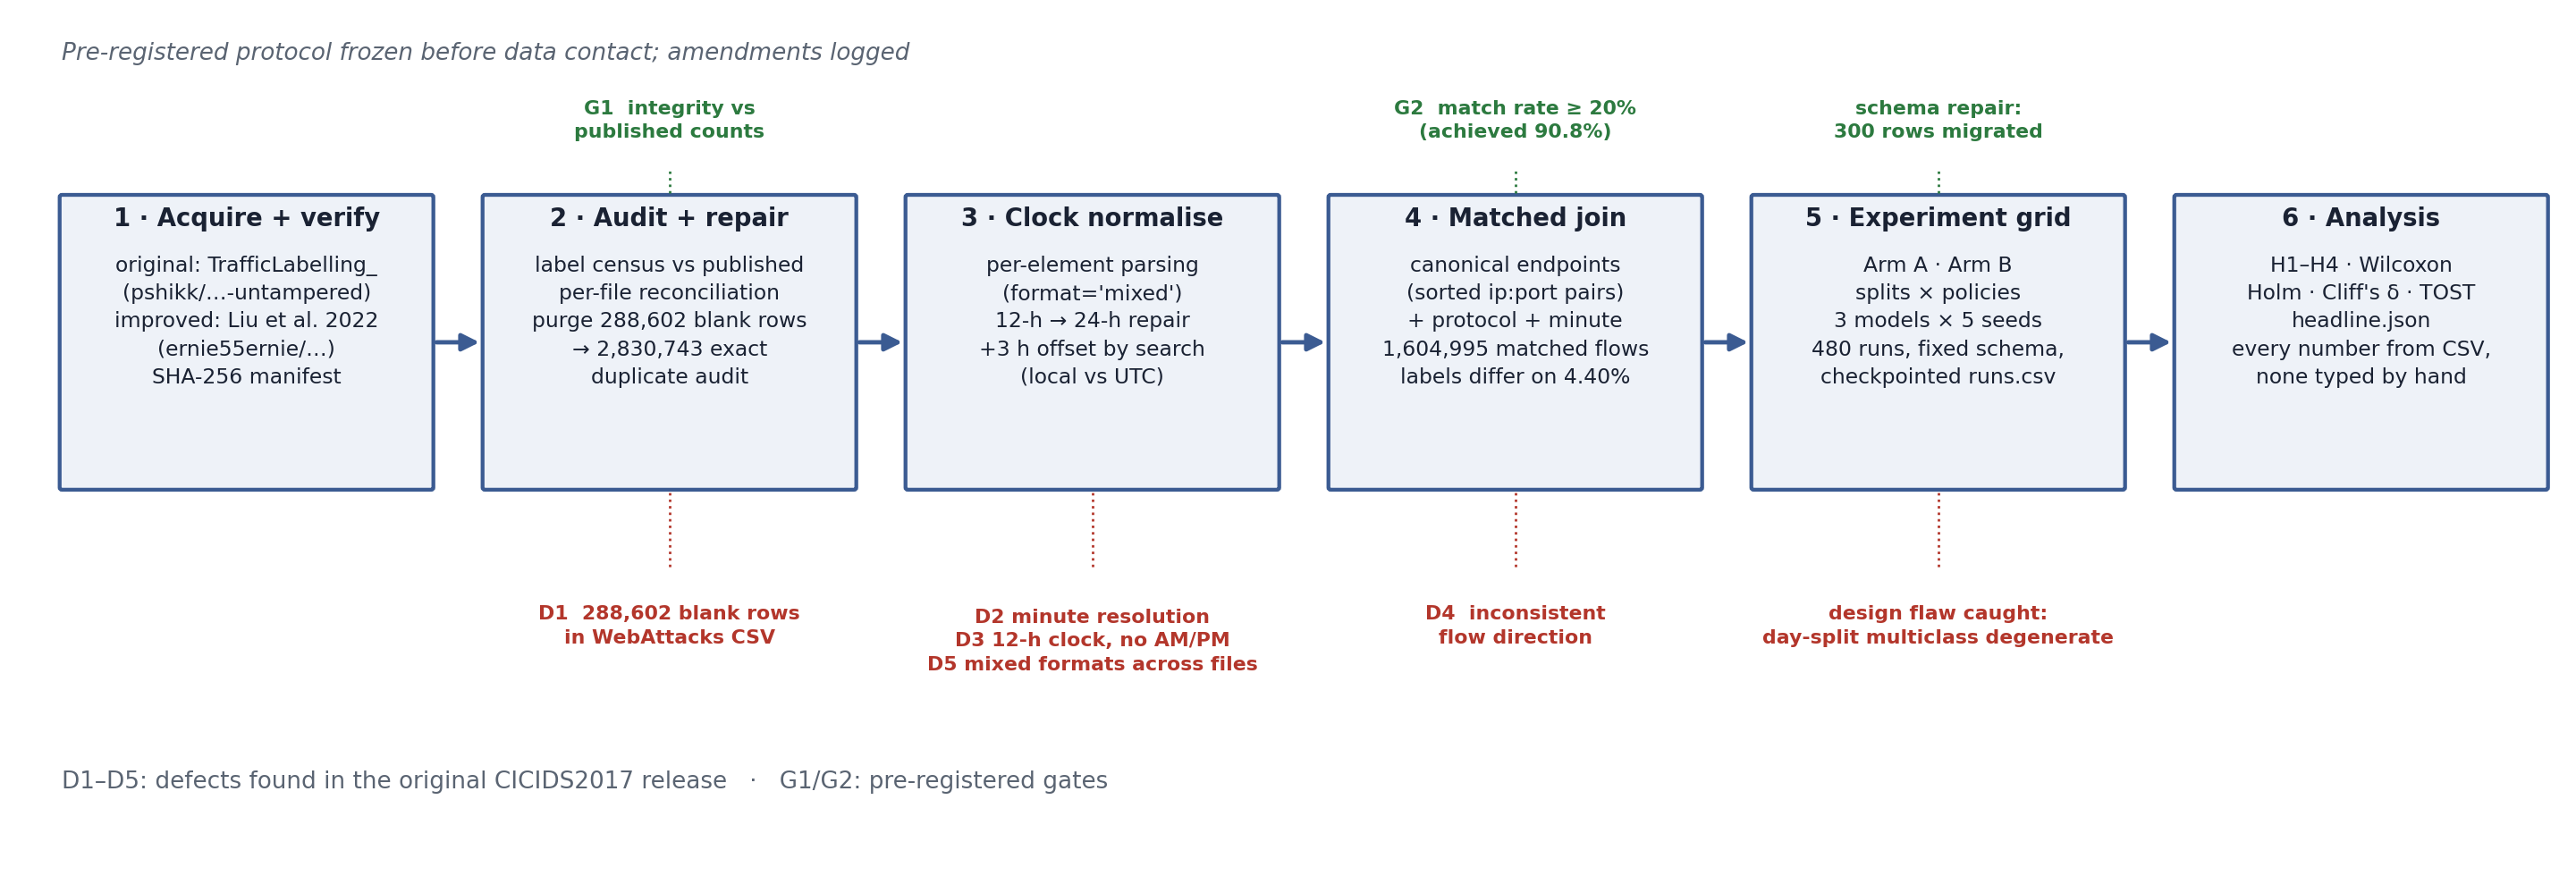


fig0b_design.png


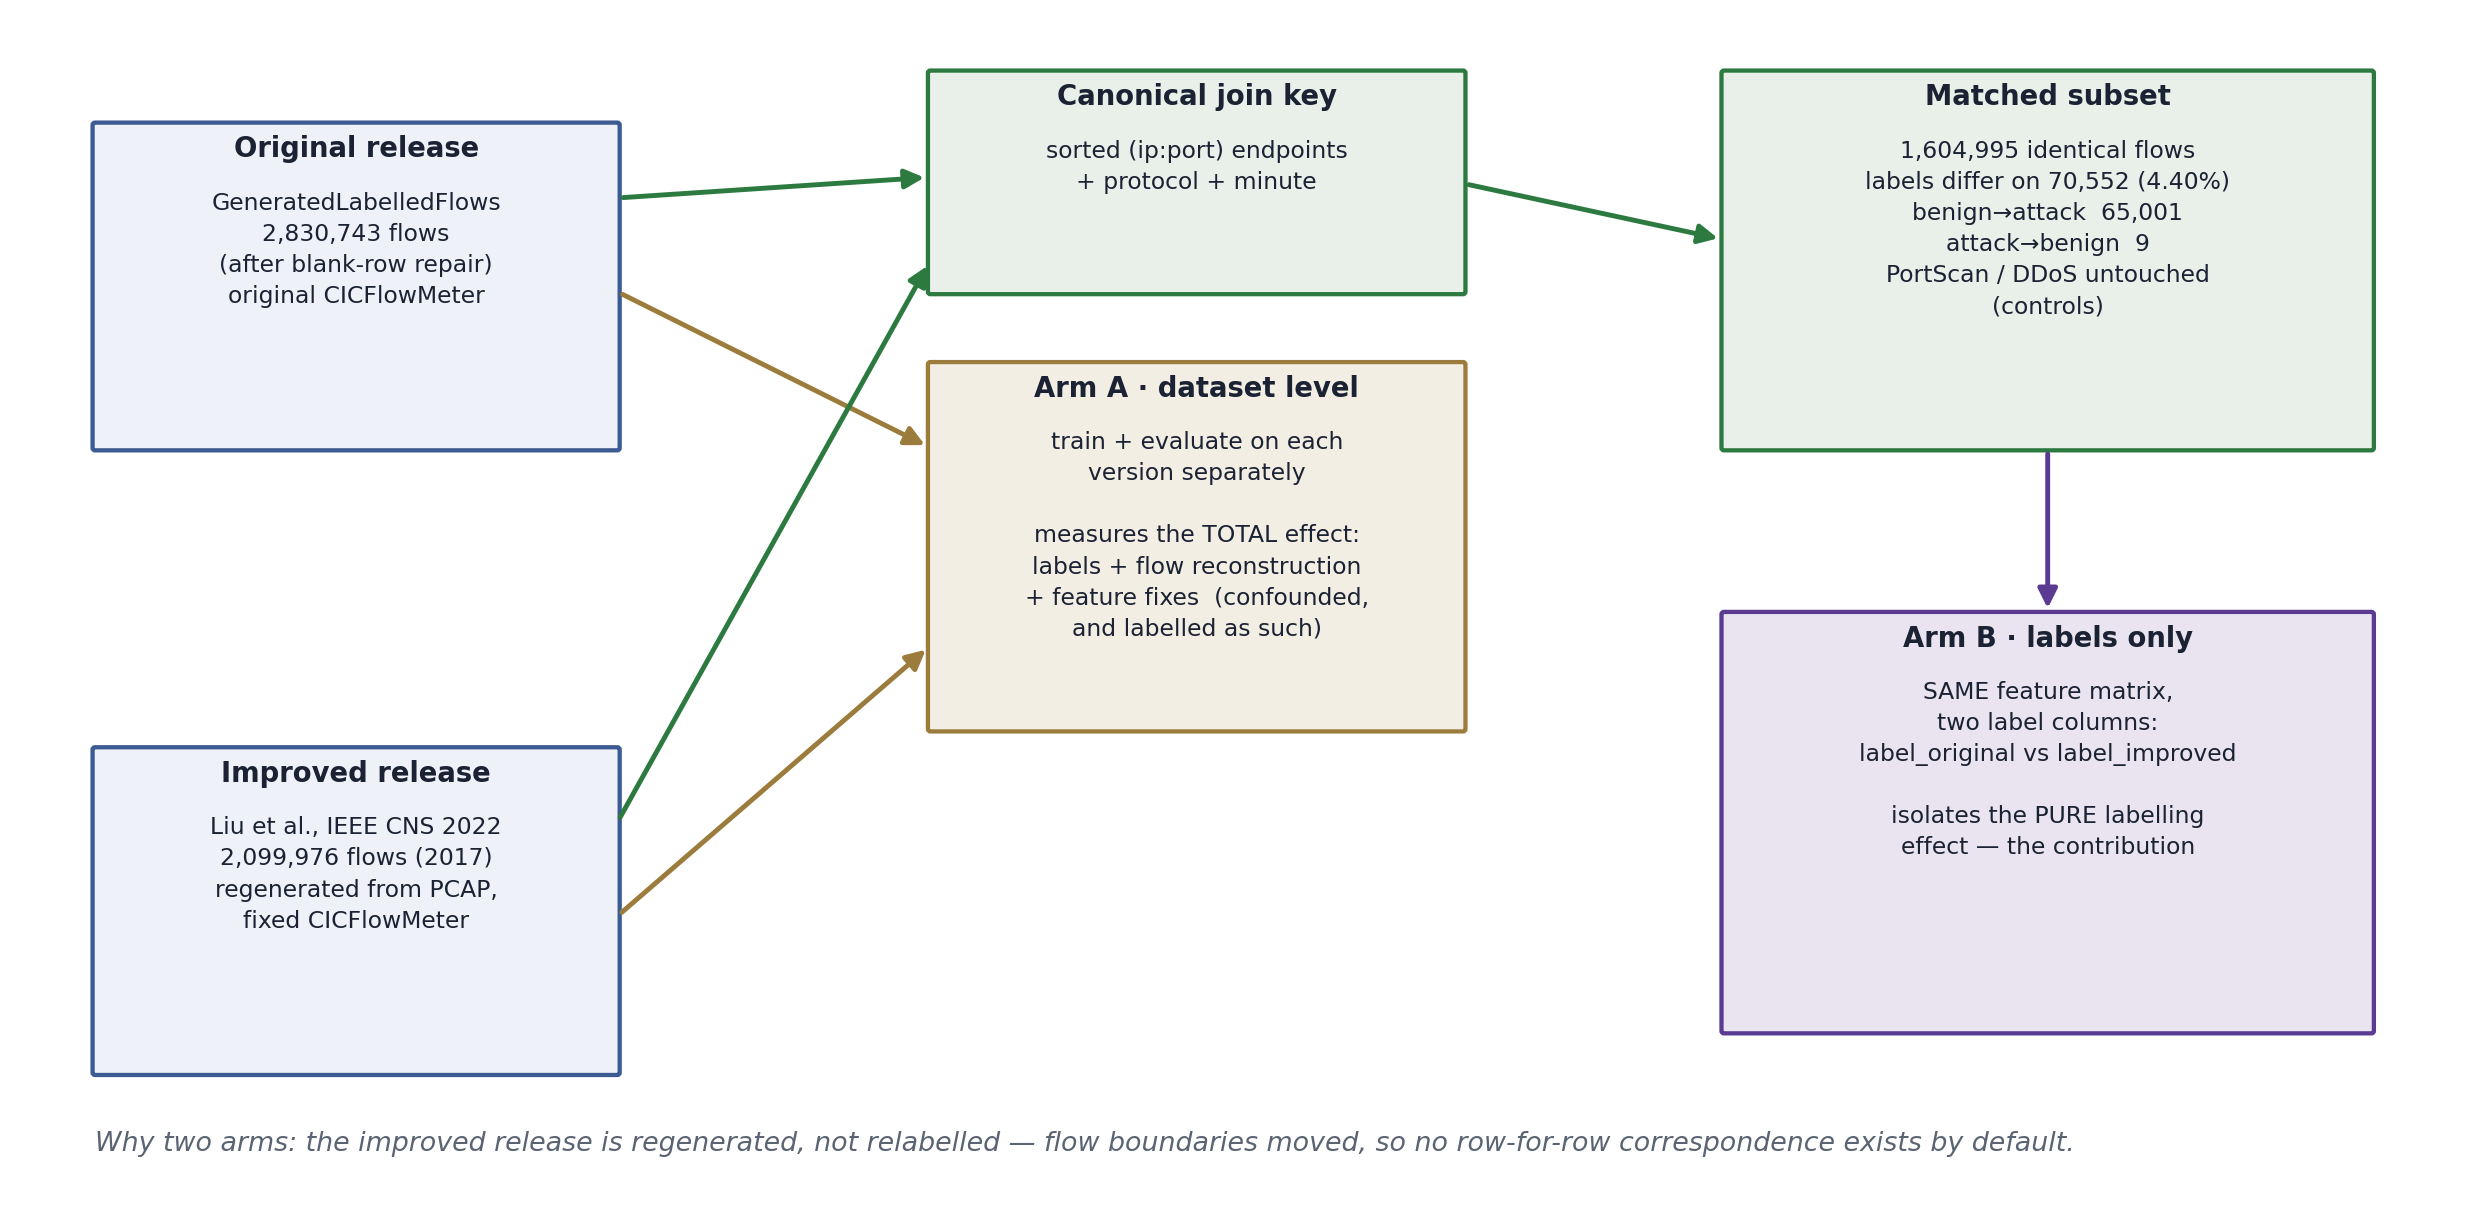


fig3_transition_heatmap.png


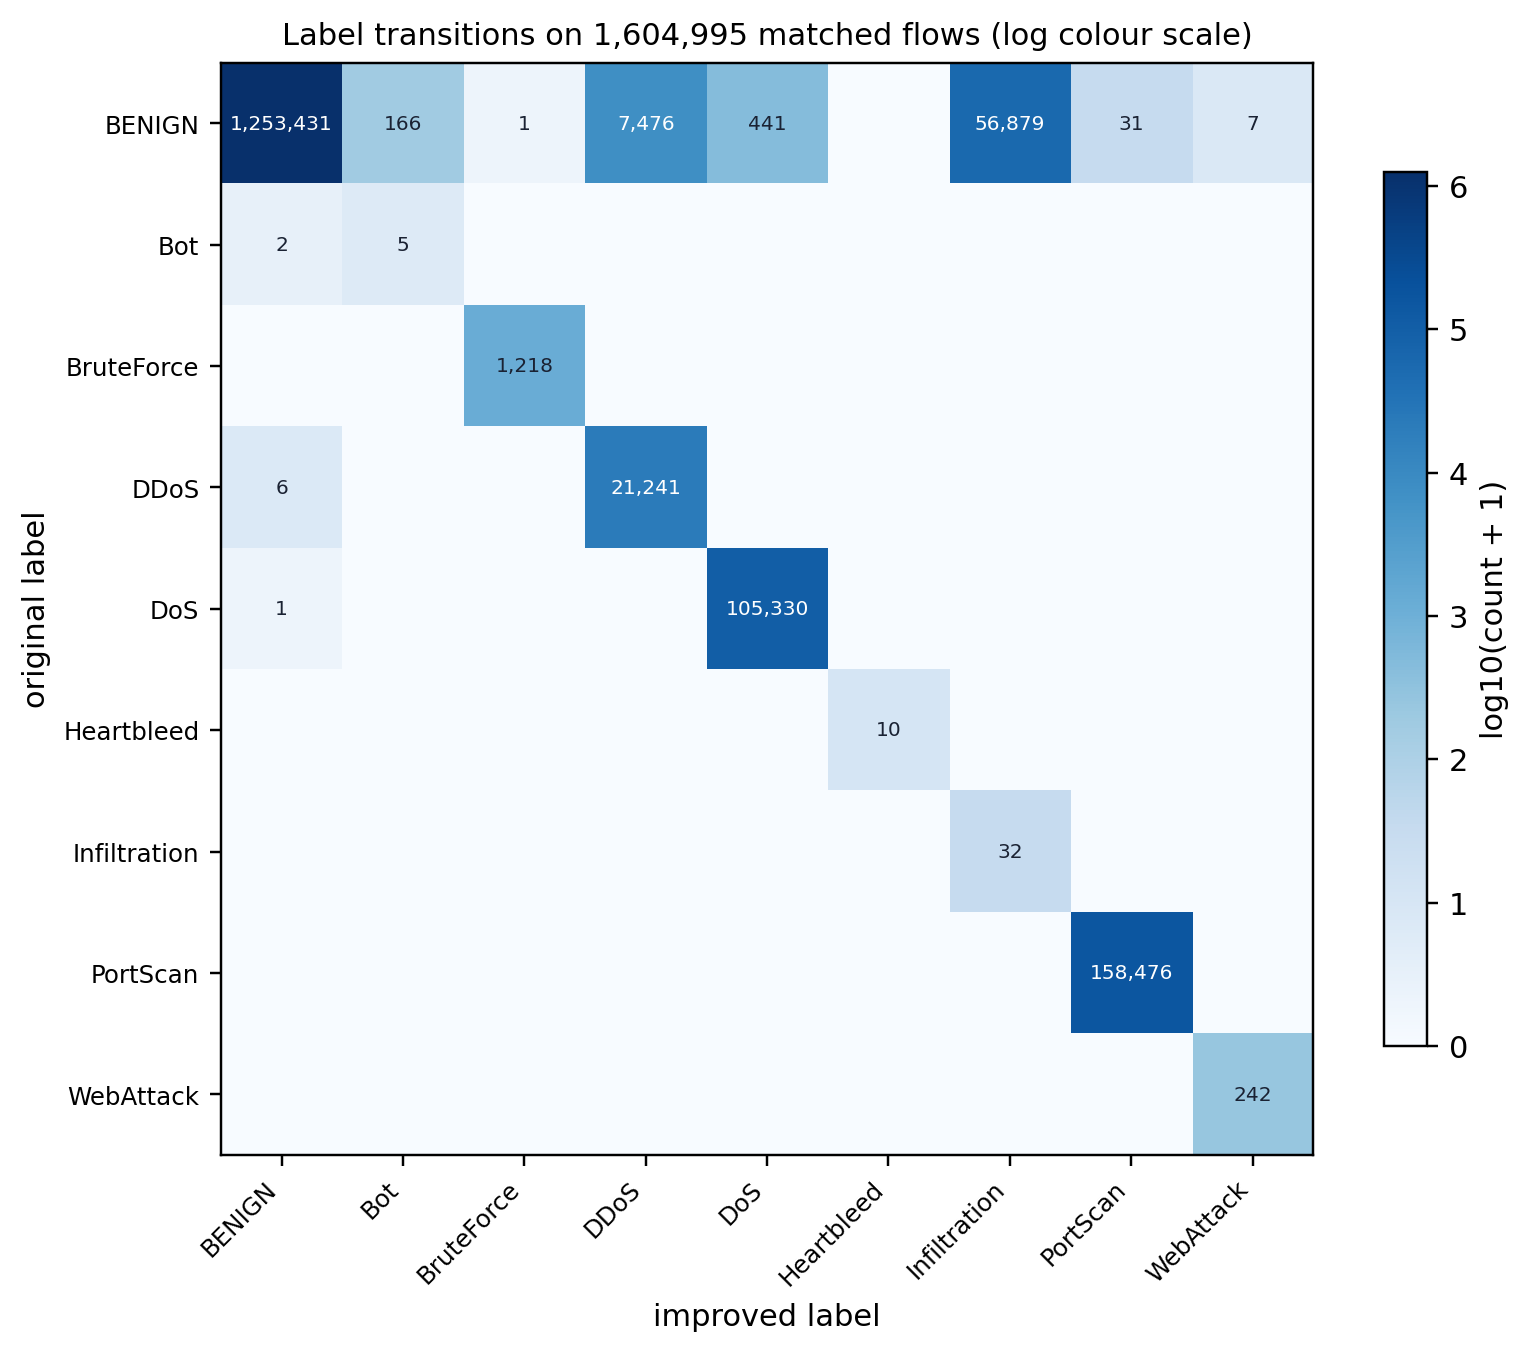


fig1_arm_a_vs_b.png


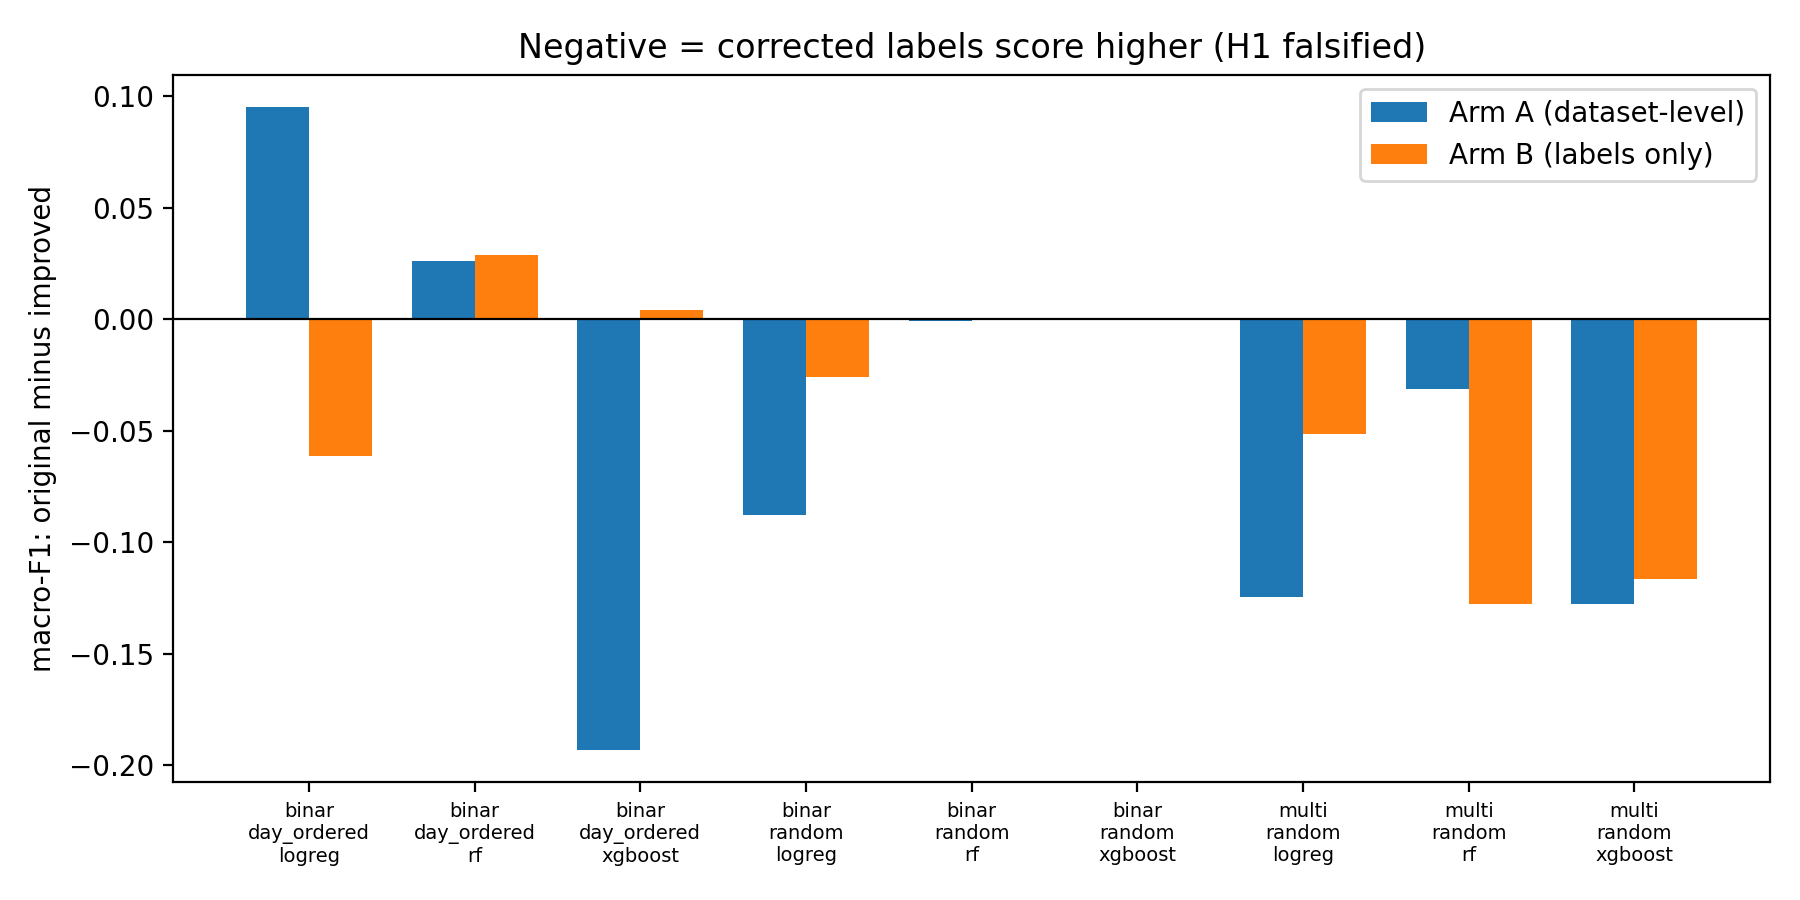


fig2_unseen_family_recall.png


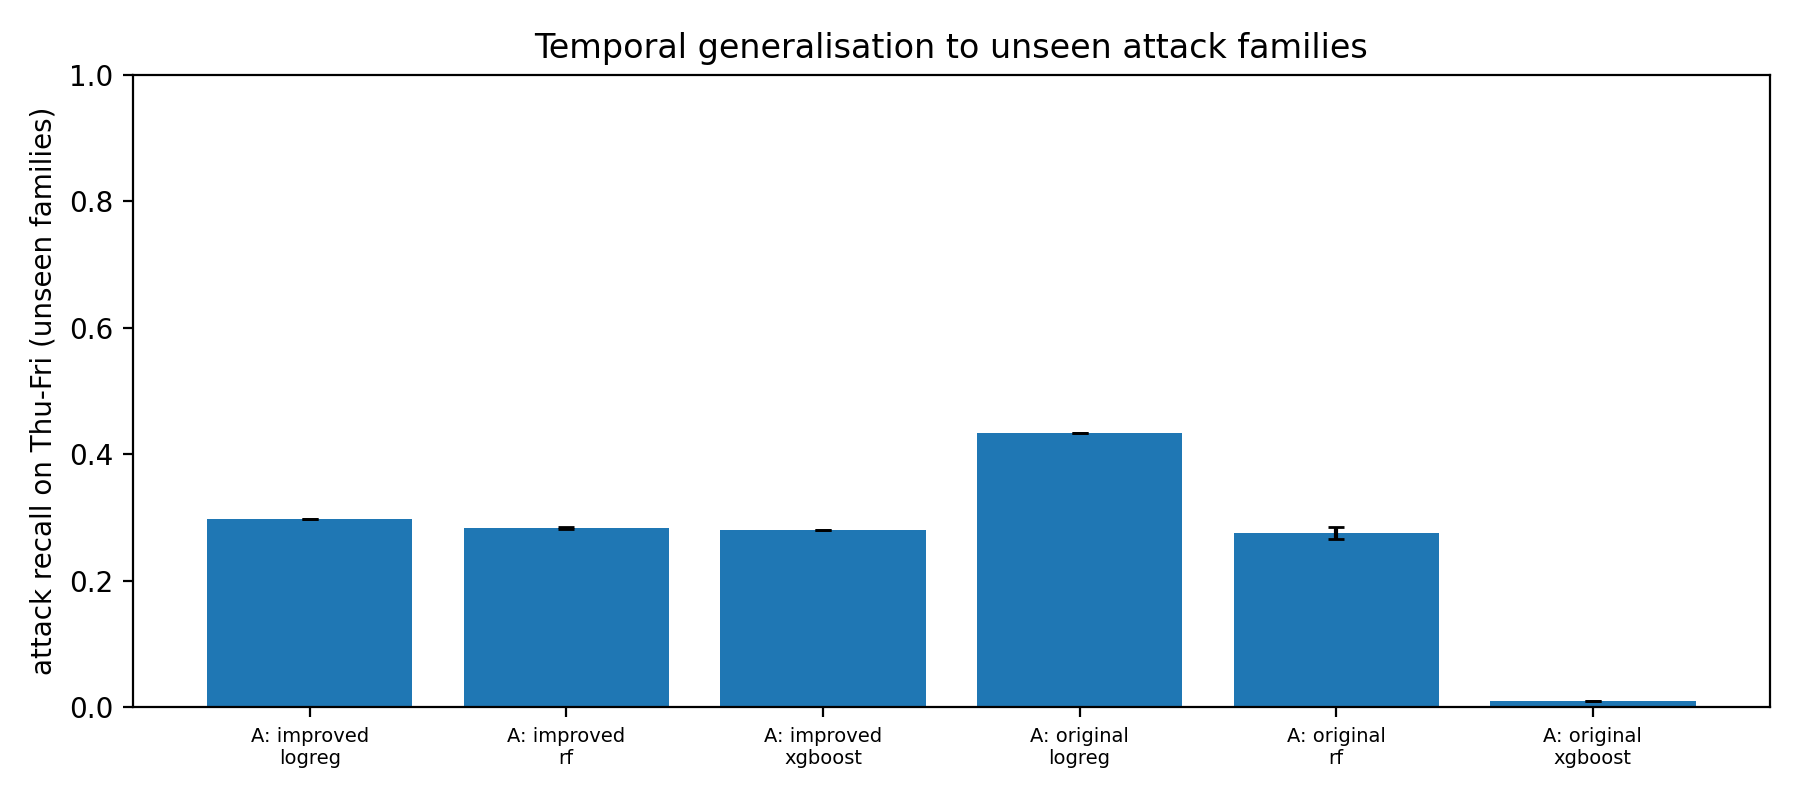

In [12]:
# --- Diagrams: pipeline, design, transition heatmap --------------------------
# Writes make_diagrams.py into the Drive project folder, runs it against
# results/ (so the heatmap finds table5), and shows the figures inline.

DIAGRAMS_SRC = r'''"""make_diagrams.py — methodology figures for the label-correction study.

Generates:
  fig0_pipeline.png       six-stage pipeline with defects (red) and gates (green)
  fig0b_design.png        the two-arm design and the matched-flow join
  fig3_transition_heatmap.png   (only if table5_label_transition_matrix.csv exists)

Pure matplotlib, no data needed for the first two. Run anywhere:
  python make_diagrams.py [output_dir]
"""
import sys, os
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

OUT = sys.argv[1] if len(sys.argv) > 1 else '.'

INK = '#1a2233'
BOX = '#eef2f8'
EDGE = '#3b5b92'
RED = '#b3362b'
GREEN = '#2c7a3f'
GREY = '#5a6472'


def box(ax, x, y, w, h, title, lines, fc=BOX, ec=EDGE, title_c=INK, fs=8.3):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.012",
                                fc=fc, ec=ec, lw=1.4))
    ax.text(x + w / 2, y + h - 0.045, title, ha='center', va='top',
            fontsize=fs + 0.7, fontweight='bold', color=title_c)
    ax.text(x + w / 2, y + h - 0.315, '\n'.join(lines), ha='center', va='top',
            fontsize=fs - 0.6, color=INK, linespacing=1.45)


def arrow(ax, x1, y1, x2, y2, color=EDGE, lw=1.6):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>',
                                 mutation_scale=13, color=color, lw=lw))


def tag(ax, x, y, text, color, fs=7.2, ha='center'):
    ax.text(x, y, text, ha=ha, va='center', fontsize=fs, color=color,
            fontweight='bold', linespacing=1.4)


# ============================================================================
# Figure 0 — pipeline
# ============================================================================
fig, ax = plt.subplots(figsize=(13.2, 4.6))
ax.set_xlim(0, 13.2); ax.set_ylim(0, 4.6); ax.axis('off')

W, H, Y = 1.92, 1.58, 2.05
xs = [0.22, 2.42, 4.62, 6.82, 9.02, 11.22]

box(ax, xs[0], Y, W, H, '1 · Acquire + verify',
    ['original: TrafficLabelling_',
     '(pshikk/…-untampered)',
     'improved: Liu et al. 2022',
     '(ernie55ernie/…)',
     'SHA-256 manifest'])
box(ax, xs[1], Y, W, H, '2 · Audit + repair',
    ['label census vs published',
     'per-file reconciliation',
     'purge 288,602 blank rows',
     '→ 2,830,743 exact',
     'duplicate audit'])
box(ax, xs[2], Y, W, H, '3 · Clock normalise',
    ['per-element parsing',
     "(format='mixed')",
     '12-h → 24-h repair',
     '+3 h offset by search',
     '(local vs UTC)'])
box(ax, xs[3], Y, W, H, '4 · Matched join',
    ['canonical endpoints',
     '(sorted ip:port pairs)',
     '+ protocol + minute',
     '1,604,995 matched flows',
     'labels differ on 4.40%'])
box(ax, xs[4], Y, W, H, '5 · Experiment grid',
    ['Arm A · Arm B',
     'splits × policies',
     '3 models × 5 seeds',
     '480 runs, fixed schema,',
     'checkpointed runs.csv'])
box(ax, xs[5], Y, W, H, '6 · Analysis',
    ['H1–H4 · Wilcoxon',
     "Holm · Cliff's δ · TOST",
     'headline.json',
     'every number from CSV,',
     'none typed by hand'])

for i in range(5):
    arrow(ax, xs[i] + W, Y + H / 2, xs[i + 1], Y + H / 2)

# defects (red, below)
tag(ax, xs[1] + W / 2, 1.30, 'D1  288,602 blank rows\nin WebAttacks CSV', RED)
tag(ax, xs[2] + W / 2, 1.22, 'D2 minute resolution\nD3 12-h clock, no AM/PM\nD5 mixed formats across files', RED)
tag(ax, xs[3] + W / 2, 1.30, 'D4  inconsistent\nflow direction', RED)
tag(ax, xs[4] + W / 2, 1.30, 'design flaw caught:\nday-split multiclass degenerate', RED)
for xc in [xs[1] + W / 2, xs[2] + W / 2, xs[3] + W / 2, xs[4] + W / 2]:
    ax.plot([xc, xc], [1.62, Y - 0.02], color=RED, lw=0.9, ls=':')

# gates (green, above)
tag(ax, xs[1] + W / 2, 4.05, 'G1  integrity vs\npublished counts', GREEN)
tag(ax, xs[3] + W / 2, 4.05, 'G2  match rate ≥ 20%\n(achieved 90.8%)', GREEN)
tag(ax, xs[4] + W / 2, 4.05, 'schema repair:\n300 rows migrated', GREEN)
for xc in [xs[1] + W / 2, xs[3] + W / 2, xs[4] + W / 2]:
    ax.plot([xc, xc], [Y + H + 0.02, 3.78], color=GREEN, lw=0.9, ls=':')

ax.text(0.22, 4.38, 'Pre-registered protocol frozen before data contact; amendments logged',
        fontsize=8.6, color=GREY, style='italic')
ax.text(0.22, 0.42, 'D1–D5: defects found in the original CICIDS2017 release   ·   '
                    'G1/G2: pre-registered gates', fontsize=8.6, color=GREY)

fig.tight_layout()
p = os.path.join(OUT, 'fig0_pipeline.png')
fig.savefig(p, dpi=220, bbox_inches='tight'); plt.close(fig)
print('saved', p)

# ============================================================================
# Figure 0b — two-arm design
# ============================================================================
fig, ax = plt.subplots(figsize=(11.6, 5.6))
ax.set_xlim(0, 11.6); ax.set_ylim(0, 5.6); ax.axis('off')

# source datasets
box(ax, 0.35, 3.55, 2.5, 1.55, 'Original release',
    ['GeneratedLabelledFlows',
     '2,830,743 flows',
     '(after blank-row repair)',
     'original CICFlowMeter'])
box(ax, 0.35, 0.55, 2.5, 1.55, 'Improved release',
    ['Liu et al., IEEE CNS 2022',
     '2,099,976 flows (2017)',
     'regenerated from PCAP,',
     'fixed CICFlowMeter'])

# Arm A
box(ax, 4.35, 2.20, 2.55, 1.75, 'Arm A · dataset level',
    ['train + evaluate on each',
     'version separately',
     '',
     'measures the TOTAL effect:',
     'labels + flow reconstruction',
     '+ feature fixes  (confounded,',
     'and labelled as such)'], fc='#f3eee4', ec='#9c7c3c')
arrow(ax, 2.85, 4.30, 4.35, 3.55, color='#9c7c3c')
arrow(ax, 2.85, 1.30, 4.35, 2.60, color='#9c7c3c')

# matched join
box(ax, 4.35, 4.30, 2.55, 1.05, 'Canonical join key',
    ['sorted (ip:port) endpoints',
     '+ protocol + minute'], fc='#e8f0e9', ec=GREEN)
box(ax, 8.15, 3.55, 3.1, 1.8, 'Matched subset',
    ['1,604,995 identical flows',
     'labels differ on 70,552 (4.40%)',
     'benign→attack  65,001',
     'attack→benign  9',
     'PortScan / DDoS untouched',
     '(controls)'], fc='#e8f0e9', ec=GREEN)
arrow(ax, 6.90, 4.82, 8.15, 4.55, color=GREEN)
arrow(ax, 2.85, 4.75, 4.35, 4.85, color=GREEN)
arrow(ax, 2.85, 1.75, 4.35, 4.45, color=GREEN)

# Arm B
box(ax, 8.15, 0.75, 3.1, 2.0, 'Arm B · labels only',
    ['SAME feature matrix,',
     'two label columns:',
     'label_original vs label_improved',
     '',
     'isolates the PURE labelling',
     'effect — the contribution'], fc='#eae4f0', ec='#5b3b92')
arrow(ax, 9.70, 3.55, 9.70, 2.75, color='#5b3b92')

ax.text(0.35, 0.18, 'Why two arms: the improved release is regenerated, not relabelled — '
                    'flow boundaries moved, so no row-for-row correspondence exists by default.',
        fontsize=8.8, color=GREY, style='italic')

fig.tight_layout()
p = os.path.join(OUT, 'fig0b_design.png')
fig.savefig(p, dpi=220, bbox_inches='tight'); plt.close(fig)
print('saved', p)

# ============================================================================
# Figure 3 — transition heatmap (data figure; only if the CSV is present)
# ============================================================================
csv = os.path.join(OUT, 'table5_label_transition_matrix.csv')
if not os.path.exists(csv):
    csv = os.path.join(OUT, 'results', 'table5_label_transition_matrix.csv')
if os.path.exists(csv):
    import pandas as pd, numpy as np
    xt = pd.read_csv(csv, index_col=0)
    fig, ax = plt.subplots(figsize=(7.6, 6.2))
    logd = np.log10(xt.values + 1)
    im = ax.imshow(logd, cmap='Blues')
    ax.set_xticks(range(len(xt.columns))); ax.set_xticklabels(xt.columns, rotation=45,
                                                              ha='right', fontsize=8)
    ax.set_yticks(range(len(xt.index))); ax.set_yticklabels(xt.index, fontsize=8)
    ax.set_xlabel('improved label'); ax.set_ylabel('original label')
    for i in range(xt.shape[0]):
        for j in range(xt.shape[1]):
            v = int(xt.values[i, j])
            if v:
                ax.text(j, i, f'{v:,}', ha='center', va='center', fontsize=6.6,
                        color='white' if logd[i, j] > logd.max() * 0.6 else INK)
    ax.set_title('Label transitions on 1,604,995 matched flows (log colour scale)',
                 fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.8, label='log10(count + 1)')
    fig.tight_layout()
    p = os.path.join(OUT, 'fig3_transition_heatmap.png')
    fig.savefig(p, dpi=220, bbox_inches='tight'); plt.close(fig)
    print('saved', p)
else:
    print('table5_label_transition_matrix.csv not found here — heatmap skipped '
          '(run this script in the Drive project folder to render it)')
'''

import subprocess, shutil, glob

script_path = os.path.join(C.DRIVE_ROOT, 'make_diagrams.py')
with open(script_path, 'w') as f:
    f.write(DIAGRAMS_SRC)
print('wrote', script_path)

r = subprocess.run(['python', 'make_diagrams.py', 'results'],
                   cwd=C.DRIVE_ROOT, capture_output=True, text=True)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr)

# collect the outputs into figures/
for f in glob.glob(os.path.join(C.DRIVE_ROOT, 'results', 'fig0*.png')) + \
         glob.glob(os.path.join(C.DRIVE_ROOT, 'results', 'fig3*.png')):
    dest = os.path.join(C.FIGURES, os.path.basename(f))
    shutil.move(f, dest)
    print('->', dest)

from IPython.display import Image, display
for name in ['fig0_pipeline.png', 'fig0b_design.png',
             'fig3_transition_heatmap.png', 'fig1_arm_a_vs_b.png',
             'fig2_unseen_family_recall.png']:
    p = os.path.join(C.FIGURES, name)
    if os.path.exists(p):
        print('\n' + name)
        display(Image(p))
    else:
        print('missing:', name)


## Writing up

The story now has three acts, all from your own tables:

1. **The benchmark's canonical release is defective** — five documented defects,
   two of which silently corrupted this study's own pipeline before being caught.
2. **Label correction changes what models learn, not how good they look** —
   H1 falsified: corrected labels score *higher*; Arm B shows it on identical
   flows; the original's 65,001 attacks-labelled-benign corrupt both training
   and scoring.
3. **Neither label set rescues temporal generalisation** — attack recall on
   unseen families is poor under both, so label correction is necessary but
   not sufficient.

Plus the meta-lesson the study accidentally ran on itself: the degenerate-split
and schema-fork incidents, caught by gates, belong in a short "lessons" section.
If a number is not in a CSV written by these notebooks, it does not go in the
manuscript.